# Learning to Implement Normalizing Flows

## TO-DO:  
- rerun RealNVP on toy distributions (since it works now)
- refactor code and put into/integrate with the modules in the code folder

In [1]:
from collections.abc import Callable
from copy import deepcopy
from IPython.display import HTML
import matplotlib
import matplotlib.animation as animation
import math
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.distributions as td
from torch.distributions.mixture_same_family import MixtureSameFamily
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
from torchvision.transforms.functional import to_pil_image
from tqdm import tqdm
from typing import List, Tuple, Dict, Iterable

import sys
sys.path.append("/mnt/data/projects/scmultimodal/code")
from plot_utils import set_plot_style

In [2]:
set_plot_style()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROJECT_DIR = pathlib.Path("/home/alzub/projects/ggdl_self_learn")
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = DATA_DIR / "models/normalizing_flows"
SAMPLE_DIR = DATA_DIR / "samples/normalizing_flows"

plt.rcParams["animation.html"] = "jshtml"
matplotlib.rcParams['animation.embed_limit'] = 2**128
plt.ioff()

# 0. Prerequisites

## 0.1 Data

### 0.1.1 Toy Distributions

In [3]:
class TwoGaussians:
    def __init__(self):
        """
        A simple class to define an uneven mixture of two Gaussians.
        """

        mixture = td.Categorical(torch.tensor([1/5, 4/5]))
        components = td.Independent(td.Normal(
            torch.Tensor([
                [0.75, 0.75],
                [0.25, 0.25]
            ]),
            torch.Tensor([
                [0.1, 0.1],
                [0.1, 0.1]
            ])
        ), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = (0, 1)
        self.ylim = (0, 1)

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution


class ExtendedUniform(td.Uniform):
    def __init__(self, low, high, validate_args=None, outside_value=-float('inf')):
        """
        A uniform distribution that returns a constant value for values outside the support
        """
        super(ExtendedUniform, self).__init__(low, high, validate_args)
        self.outside_value = outside_value

    def log_prob(self, value):
        # Check if the value is within the support
        in_support = (value >= self.low) & (value <= self.high)
        safe_value = torch.where(in_support, value, self.low)
        log_prob = super().log_prob(safe_value)
        
        # Set log_prob to self.outside_value for values outside the support
        log_prob = torch.where(in_support, log_prob, torch.full_like(log_prob, self.outside_value))
        return log_prob
    
    @td.constraints.dependent_property(is_discrete=False, event_dim=0)
    def support(self):
        return td.constraints.real

class Chequerboard:
    def __init__(self, grid_size=3, bounds=[0.0, 1.0]):
        """
        A simple class to define the Chequerboard distribution.
        """

        square_size = (bounds[1] - bounds[0]) / grid_size

        weights = []
        low_list = []
        high_list = []
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0:
                    low_x = bounds[0] + i * square_size
                    high_x = low_x + square_size
                    low_y = bounds[0] + j * square_size
                    high_y = low_y + square_size
                    
                    low_list.append([low_x, low_y])
                    high_list.append([high_x, high_y])
                    weights.append(1.0)

        mixture = td.Categorical(torch.tensor(weights))
        #components = td.Independent(td.uniform.Uniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        components = td.Independent(ExtendedUniform(torch.tensor(low_list), torch.tensor(high_list)), 1)
        self.distribution = MixtureSameFamily(mixture, components)

        self.xlim = bounds
        self.ylim = bounds

    def __call__(self):
        """
        Return the distribution.
        Returns:
        distribution: [torch.distributions.Distribution]
        """
        return self.distribution

### 0.1.2 MNIST

In [4]:
batch_size = 256

mnist_train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=True, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    ),
    batch_size=batch_size, shuffle=True
)
mnist_test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(
        PROJECT_DIR / "data", train=False, download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
    ),
    batch_size=batch_size, shuffle=True
)

### 0.2 My Own Basic NN Components

### 0.2.1 Basic MLP

In [5]:
class FCLayer(nn.Module):
    """
    WIP: add dropout
    """
    def __init__(
            self, in_feats: int, out_feats: int, use_batchnorm: bool=True,
            act_fun=nn.ReLU
        ) -> None:
        super().__init__()

        modules = [nn.Linear(in_feats, out_feats)]
        if use_batchnorm:
            modules.append(nn.BatchNorm1d(out_feats))
        if act_fun is not None:
            modules.append(act_fun())
        
        self.fc_layer = nn.Sequential(*modules)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc_layer(x)

class MLP(nn.Module):
    """
    WIP: add dropout
    """
    def __init__(
            self, n_feats: int, out_size: int, 
            hidden_sizes: None|int|list[int]=None,
            act_funs: list[nn.Module]|nn.Module=nn.ReLU, flatten=False
        ) -> None:
        super().__init__()

        if hidden_sizes:
            if isinstance(hidden_sizes, int):
                hidden_sizes = [hidden_sizes]
            # parameterize the number of hidden layers and nodes
            layer_sizes = [n_feats] + hidden_sizes + [out_size]
            n_layers = len(layer_sizes) - 1
            in_layer_sizes = layer_sizes[0:n_layers]
            out_layer_sizes = layer_sizes[1:n_layers + 1]

            # parameterize activation functions
            if not isinstance(act_funs, list):
                act_funs = [act_funs]*n_layers

            fc_block_list = [
                FCLayer(n_in, n_out, use_batchnorm=False, act_fun=a_fun)
                for n_in, n_out, a_fun
                in zip(in_layer_sizes, out_layer_sizes, act_funs)
            ]
        else:
            fc_block_list = [FCLayer(n_feats, out_size, act_fun=act_funs)]
        
        if isinstance(flatten, bool) and flatten == True:
            fc_block_list.insert(0, nn.Flatten())
        elif not isinstance(flatten, bool):
            fc_block_list.append(nn.Unflatten(-1, flatten))
        
        self.network = nn.Sequential(*fc_block_list)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

### 0.2.2 Convolutional Layers

In [6]:
class Conv2DLayer(nn.Module):
    def __init__(
        self, in_chans: int, out_chans: int, conv_kernel_size: int,
        conv_pad_size: int, conv_stride_size: int=1, pool: None|str="max",
        pool_kernel_size: None|int=None, pool_stride: None|int=None,
        skip: bool=False, use_batchnorm: bool=False, act_fun=nn.ReLU
    ) -> None:
        super().__init__()
    
        modules = []
        modules.append(nn.Conv2d(
            in_chans, out_chans, kernel_size=conv_kernel_size,
            padding=conv_pad_size, stride=conv_stride_size
        ))
        
        if pool:
            if pool == "max":
                modules.append(nn.MaxPool2d(
                    pool_kernel_size, stride=pool_stride))
            elif pool == "mean":
                modules.append(nn.AvgPool2d(
                    pool_kernel_size, stride=pool_stride))
        
        if use_batchnorm:
            modules.append(nn.BatchNorm2d(out_chans))
        if act_fun is not None:
            modules.append(act_fun())
        
        self.conv2d_layer = nn.Sequential(*modules)

        self.skip_flag = skip
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_out = self.conv2d_layer(x)
        if self.skip_flag:
            return x + x_out
        else:
            return x_out

class TransposeConv2DLayer(nn.Module):
    def __init__(
        self, in_chans: int, out_chans: int, kernel_size: int, in_pad_size: int,
        out_pad_size: int, stride_size: int, use_batchnorm: bool=False,
        act_fun=nn.ReLU
    ) -> None:
        super().__init__()
        
        modules = []
        modules.append(nn.ConvTranspose2d(
            in_chans, out_chans, kernel_size=kernel_size, stride=stride_size,
            padding=in_pad_size, output_padding=out_pad_size
        ))

        if use_batchnorm:
            modules.append(nn.BatchNorm2d(out_chans))
        if act_fun is not None:
            modules.append(act_fun())
        
        self.tconv2d_layer = nn.Sequential(*modules)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.tconv2d_layer(x)

### 0.2.3 Attention/Transformer

In [7]:
class CausalSDPA(nn.Module):
    def __init__(self, n_channels: int, head_channels: int) -> None:
        assert n_channels % head_channels == 0
        super().__init__()

        self.norm = nn.LayerNorm(n_channels)
        self.qkv = nn.Linear(n_channels, n_channels*3)
        self.proj = nn.Linear(n_channels, n_channels)
        self.n_heads = n_channels // head_channels
        self.sqrt_scale = head_channels**(-0.25)

        self.sample = False
        self.k_cache: Dict[str, List[torch.Tensor]] = {"cond": [], "uncond": []}
        self.v_cache: Dict[str, List[torch.Tensor]] = {"cond": [], "uncond": []}
    
    def forward(
        self, x: torch.Tensor, mask: torch.Tensor|None=None, temp: float=1.0,
        which_cache: None|str=None
    ) -> torch.Tensor:
        B, T, C = x.size()
        x = self.norm(x.float()).type(x.dtype)
        q, k, v = (
            # (batch_size, no_of_tokens, no_of_channels*3)
            self.qkv(x)
                # (batch_size, no_of_tokens, no_of_heads*3, head_dimensionality)
                .reshape(B, T, 3*self.n_heads, -1)
                # (batch_size, no_of_heads*3, no_of_tokens, head_dimensionality)
                .transpose(1, 2).contiguous()
                # 3 * (batch_size, no_of_heads, no_of_tokens, head_dimensionality)
                .chunk(3, dim=1)
        )

        if self.sample and which_cache is not None:
            self.k_cache[which_cache].append(k)
            self.v_cache[which_cache].append(v)
            k = torch.cat(self.k_cache[which_cache], dim=2)
            v = torch.cat(self.v_cache[which_cache], dim=2)

        scale = self.sqrt_scale**2 / temp
        if mask is not None:
            mask = mask.bool()

        x = (
            # (batch_size, no_of_heads, no_of_tokens, head_dimensionality)
            F.scaled_dot_product_attention(q, k, v, attn_mask=mask, scale=scale)
                # (batch_size, no_of_tokens, no_of_heads, head_dimensionality)
                .transpose(1, 2)
                # (batch_size, no_of_tokens, no_of_channels)
                .reshape(B, T, C)
        )
        return self.proj(x)

## 0.3 Training Code

### 0.3.1 Optimizer Implementations

TO-DO: make own implementations.

In [8]:
class CosineLRSchedule(torch.nn.Module):
    counter: torch.Tensor

    def __init__(self, optimizer, warmup_steps: int, total_steps: int, min_lr: float, max_lr: float):
        super().__init__()
        self.register_buffer('counter', torch.zeros(()))
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.set_lr(min_lr)

    def set_lr(self, lr: float) -> float:
        if self.min_lr <= lr <= self.max_lr:
            for pg in self.optimizer.param_groups:
                pg['lr'] = lr
        return max(self.min_lr, min(self.max_lr, lr))

    def step(self) -> float:
        with torch.no_grad():
            counter = self.counter.add_(1).item()
        if self.counter <= self.warmup_steps:
            new_lr = self.min_lr + counter / self.warmup_steps * (self.max_lr - self.min_lr)
            return self.set_lr(new_lr)

        t = (counter - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        new_lr = self.min_lr + 0.5 * (1 + math.cos(math.pi * t)) * (self.max_lr - self.min_lr)
        return self.set_lr(new_lr)

# 1. NF Implementations

## 1.1 Basic Components

In [9]:
class Permutation(nn.Module):
    def __init__(self, seq_len: int) -> None:
        super().__init__()
        self.seq_len = seq_len
    
    def forward(
        self, x: torch.Tensor, dim: int=1, inverse: bool=False
    ) -> torch.Tensor:
        raise NotImplementedError

class PermutationIdentity(Permutation):
    def forward(
        self, x: torch.Tensor, dim: int=1, inverse: bool=False
    ) -> torch.Tensor:
        return x

class PermutationFlip(Permutation):
    def forward(
        self, x: torch.Tensor, dim: int=1, inverse: bool=False
    ) -> torch.Tensor:
        return x.flip(dims=[dim])

class GaussianBase(nn.Module):
    normalization_constant = 0.5 * torch.log(
        torch.Tensor([2 * torch.pi]).to(DEVICE))
    def __init__(self, dimensionality: Tuple) -> None:
        super().__init__()

        self.dim = dimensionality
        self.mean = nn.Parameter(torch.zeros(*self.dim), requires_grad=False)
        self.std = nn.Parameter(torch.ones(*self.dim), requires_grad=False)
    
    def forward(self) -> td.Distribution:
        return td.Independent(td.Normal(self.mean, self.std), len(self.dim))

In [10]:
class NormalizingFlow(nn.Module):
    def __init__(
        self, base_dist: nn.Module, trafo_blocks: nn.ModuleList,
        device: str="cpu"
    ) -> None:
        super().__init__()

        self.device = device
        self.base = base_dist.to(device=self.device)
        self.transformations = trafo_blocks
    
    def forward(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.reverse_norm(z, y=y, **kwargs)
    
    def reverse_norm(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        log_dets = torch.zeros(z.size(0), device=z.device)
        for T in self.transformations:
            z, log_det_J = T.reverse_norm(z, y=y, **kwargs)
            log_dets = log_dets + log_det_J
        
        return z, log_dets
    
    def forward_flow(
        self, sample_shape: Tuple=(1,), y: torch.Tensor|None=None,
        show_path: bool=False, **kwargs
    ) -> torch.Tensor:

        xs = [self.base().sample(sample_shape)]

        for T in reversed(self.transformations):
            xs.append(T.forward_flow(xs[-1], y=y, **kwargs))

        if not show_path:
            return xs[-1]
        else:
            return torch.stack(xs, dim=0)

## 1.1 Autoregressive Flows

### 1.1.1 RealNVP

In [11]:
def checkerboard_mask_1d(
    l: int, invert: bool=False, device: str=None) -> torch.Tensor:
    m = torch.zeros(l)
    m[:l//2] = 1.0
    if invert:
        m = 1 - m
    return m.view(1, l).to(device)

def checkerboard_mask_2d(
    h: int, w: int, invert: bool=False, device: str=None) -> torch.Tensor:
    yy, xx = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")
    m = (yy + xx) % 2
    if invert:
        m = 1 - m
    return m.to(torch.float32).view(1, 1, h, w).to(device)

def channel_mask(c: int, invert: bool=False, device: str=None) -> torch.Tensor:
    m = torch.zeros(c)
    m[:c//2] = 1.0
    if invert:
        m = 1 - m
    return m.view(1, c, 1, 1).to(device)

def peprocess_realnvp(
    x: torch.Tensor, n_bins: int=256, alpha: float=1e-6
) -> Tuple[torch.Tensor, torch.Tensor]:
    assert x.dim() == 4
    B = x.size(0)

    x = (x + 1.0) * 0.5

    x = x * (n_bins - 1)
    x = (x + torch.rand_like(x)) / n_bins
    
    # soft clamping
    x = x * (1 - 2*alpha) + alpha
    x_tilde = torch.log(x) - torch.log1p(-x)
    log_det = (-torch.log(x) - torch.log1p(-x)).view(B, -1).sum(dim=1)

    return x_tilde, log_det

def postprocess_realnvp(x_tilde: torch.Tensor) -> torch.Tensor:
    x = torch.sigmoid(x_tilde)
    return x

class FILMedCNN(nn.Module):
    def __init__(
        self, conv_net: nn.Module|nn.Sequential, n_classes: int,
        condition_dim: int, input_dim: int, hidden_dim: int,
        n_convs: int=4, act_fun=nn.ReLU
    ) -> None:
        super().__init__()

        self.proj_in = nn.Conv2d(input_dim, hidden_dim, kernel_size=1)

        nets = []
        for _ in range(n_convs):
            nets.append(deepcopy(conv_net))
            if act_fun is not None:
                nets.append(act_fun())
        self.conv_net = nn.Sequential(*nets)
        self.class_embed = nn.Parameter(
            torch.randn(n_classes, condition_dim)*1e-2)
        self.film = nn.Linear(condition_dim, 2*hidden_dim)
        if act_fun is not None:
            self.act_fun = act_fun()
        else:
            self.act_fun = None
        
        self.proj_out = nn.Conv2d(hidden_dim, 2*input_dim, kernel_size=1)
        nn.init.zeros_(self.proj_out.weight)
        nn.init.zeros_(self.proj_out.bias)
        
    def forward(
        self, x: torch.Tensor, y: torch.Tensor|None=None) -> torch.Tensor:
        # (batch_size, no_of_channels, height, width)
        # -> (batch_size, hidden_channels, height, width)
        x = self.proj_in(x)

        # (batch_size, cond_dim)
        if y is not None:
            # if some classes are missing (e.g. for unconditional training
            # with dropout)
            if (y < 0).any():
                m = (y < 0).float().view(-1, 1)
                class_embed = (
                    (1 - m) * self.class_embed[y]
                        + m * (
                            self.class_embed.mean(dim=0)
                                .unsqueeze(0)
                                .expand(x.size(0), -1)
                        )
                )
            else:
                class_embed = self.class_embed[y]
            c = class_embed
        else:
            c = (
                self.class_embed.mean(dim=0)
                    .unsqueeze(0)
                    .expand(x.size(0), -1)
            )
        
        # 2 * (batch_size, hidden_channels)
        gamma, beta = torch.chunk(self.film(c), 2, dim=-1)
        if x.dim() == 4:
            # 2 * (batch_size, hidden_channels, height, width)
            gamma = gamma[:, :, None, None]
            beta = beta[:, :, None, None]
        else:
            pass
        # stabilize in case gamma is near 0
        gamma = gamma + 1.0

        # (batch_size, hidden_channels, height, width)
        x = self.conv_net(x)
        x = x*gamma + beta
        if self.act_fun is not None:
            x = self.act_fun(x)
        # (batch_size, 2*no_of_channels, height, width)
        x = self.proj_out(x)
        
        # 2 * (batch_size, hidden_channels, height, width)
        return torch.chunk(x, 2, dim=1)

class ActNorm2d(nn.Module):
    """
    Invertible per-channel affine normalization for (B,C,H,W).
    Data-dependent init on first forward pass.
    """
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.initialized = False
        self.bias = nn.Parameter(torch.zeros(1, num_channels, 1, 1))
        self.log_scale = nn.Parameter(torch.zeros(1, num_channels, 1, 1))

    @torch.no_grad()
    def _data_init(self, x: torch.Tensor):
        # x: (B,C,H,W)
        mean = x.mean(dim=(0, 2, 3), keepdim=True)
        std = x.std(dim=(0, 2, 3), keepdim=True).clamp_min(self.eps)
        self.bias.data = -mean
        self.log_scale.data = torch.log(1.0 / std)
        self.initialized = True

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if not self.initialized:
            self._data_init(x)

        y = (x + self.bias) * torch.exp(self.log_scale)
        # log|det J| per sample
        _, C, H, W = x.shape
        logdet = (self.log_scale.view(1, C).sum(dim=1) * (H * W)).expand(x.size(0))
        return y, logdet

    def inverse(self, y: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = y * torch.exp(-self.log_scale) - self.bias
        _, C, H, W = y.shape
        logdet = (-self.log_scale.view(1, C).sum(dim=1) * (H * W)).expand(y.size(0))
        return x, logdet

class RealNVPCoupling(nn.Module):
    def __init__(
        self, coupling_net: nn.Module|nn.Sequential, mask: torch.Tensor,
        clamp_factor: float=5.0
    ) -> None:
        super().__init__()

        self.coupling_net = coupling_net
        self.register_buffer("mask", mask)

        self.clamp_factor = clamp_factor
    
    def forward(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.reverse_norm(z, y=y, **kwargs)
    
    def reverse_norm(
        self, z: torch.Tensor, y: torch.Tensor|None=None,
        clamp_factor: float=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        if clamp_factor is None:
            clamp_factor = self.clamp_factor

        # (batch_size, 2*sequence_length)
        z_a = z * self.mask

        log_scale, shift = self.coupling_net(z_a, y=y)
        log_scale = self._clamp(
            log_scale * (1 - self.mask), clamp_factor=clamp_factor)
        shift = shift * (1 - self.mask)
        scale = torch.exp(-log_scale.float()).type(log_scale.dtype)

        z = z_a + (1 - self.mask) * ((z - shift) * scale)
        log_det_J = (-(log_scale)).view(z.size(0), -1).sum(dim=1)

        return z, log_det_J

    def forward_flow(
        self, x: torch.Tensor, y: torch.Tensor|None=None,
        clamp_factor: float=None, guidance: float=0, guide_what: str="ab"
    ) -> torch.Tensor:
        """
        In guide_what:
         - a corresponds to (log) scale (exponent)
         - b corresponds to shift
        """
        if clamp_factor is None:
            clamp_factor = self.clamp_factor

        # (batch_size, sequence_length)
        x_a = x * self.mask

        log_scale, shift = self.coupling_net(x_a, y=y)

        if guidance > 0 and guide_what:
            log_scale_u, shift_u = self.coupling_net(x_a, y=None)
            g = guidance
            
            if "a" in guide_what:
                log_scale = log_scale + g * (log_scale - log_scale_u)
            if "b" in guide_what:
                shift = shift + g * (shift - shift_u)
        
        log_scale = self._clamp(
            log_scale * (1 - self.mask), clamp_factor=clamp_factor)
        shift = shift * (1 - self.mask)
        scale = torch.exp(log_scale.float()).type(log_scale.dtype)

        x = x_a + (1 - self.mask) * (x * scale + shift)
        return x
    
    @staticmethod
    def _clamp(log_scale: torch.Tensor, clamp_factor: float) -> torch.Tensor:
        return clamp_factor * torch.tanh(log_scale/clamp_factor)

class RealNVPBlock(nn.Module):
    def __init__(
        self, coupling_nets: nn.ModuleList, norms: nn.ModuleList,
        masks: Iterable[torch.Tensor]|torch.Tensor, squeeze: bool=True,
        **kwargs
    ) -> None:
        assert len(coupling_nets) == len(masks) == len(norms)
        super().__init__()

        self.couplings = nn.ModuleList([
            RealNVPCoupling(c_net, m, **kwargs)
            for c_net, m in zip(coupling_nets, masks)
        ])
        self.norms = norms
        self.squeeze_flag = squeeze
    
    def forward(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.reverse_norm(z, y=y, **kwargs)
    
    def reverse_norm(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        log_dets = torch.zeros(z.size(0), device=z.device)
        for coup, norm in zip(self.couplings, self.norms):
            z, log_det_J_coup = coup.reverse_norm(z, y=y, **kwargs)
            z, log_det_J_norm = norm(z)
            log_dets = log_dets + log_det_J_coup + log_det_J_norm
        
        if self.squeeze_flag:
            z = self._squeeze2x(z)
        
        return z, log_dets

    def forward_flow(
        self, x: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> torch.Tensor:
        if self.squeeze_flag:
            x = self._unsqueeze2x(x)

        for coup, norm in zip(reversed(self.couplings), reversed(self.norms)):
            x, _ = norm.inverse(x)
            x = coup.forward_flow(x, y=y, **kwargs)
        
        return x

    def _squeeze2x(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.size()
        x = x.view(B, C, H//2, 2, W//2, 2)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C*4, H//2, W//2)
    
    def _unsqueeze2x(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.size()
        x = x.view(B, C//4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3).contiguous()
        return x.view(B, C//4, H*2, W*2)

### 1.1.2 TarFlow

In [12]:
class ResidualAttentionBlock(nn.Module):
    def __init__(self, channels: int, head_channels: int, expansion: int=4):
        super().__init__()
        self.attention = CausalSDPA(channels, head_channels)
        self.mlp_norm = nn.LayerNorm(channels)
        self.mlp = MLP(
            channels, channels, [channels*expansion], [nn.GELU, None])

    def forward(
        self, x: torch.Tensor, attn_mask: torch.Tensor|None=None,
        attn_temp: float=1.0, which_cache: str|None=None
    ) -> torch.Tensor:
        x = x + self.attention(
            x, attn_mask, attn_temp, which_cache=which_cache)
        x = x + self.mlp(self.mlp_norm(x.float()).type(x.dtype))
        return x

class TarFlowBlock(nn.Module):
    """
    TO-DO: Add the volume-preserving mode as an option
    """
    def __init__(
        self,
        permutation: Permutation, attention_block: nn.ModuleList, in_chans: int,
        hidden_chans: int, n_patches: int, n_classes: int=0
    ) -> None:
        super().__init__()
        
        self.perm = permutation
        self.attn_blocks = attention_block
        self.proj_in = nn.Linear(in_chans, hidden_chans)
        self.pos_embed = nn.Parameter(torch.randn(n_patches, hidden_chans)*1e-2)
        if n_classes > 0:
            self.class_embed = nn.Parameter(
                torch.randn(n_classes, 1, hidden_chans)*1e-2)
        else:
            self.class_embed = None
        
        self.proj_out = nn.Linear(hidden_chans, in_chans*2)
        self.proj_out.weight.data.fill_(0.0)

        self.register_buffer(
            "attn_mask",
            torch.tril(torch.ones(n_patches, n_patches, dtype=torch.bool))
        )
    
    def forward(
        self, z: torch.Tensor, y: torch.Tensor|None=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.reverse_norm(z, y=y)

    def reverse_norm(
        self, z: torch.Tensor, y: torch.Tensor|None=None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # (batch_size, no_of_tokens, input_channels)
        z = self.perm(z)
        z_tilde = z
        # (batch_size, no_of_tokens, hidden_channels)
        z = self.proj_in(z) + self.perm(self.pos_embed, dim=0)
        if self.class_embed is not None:
            if y is not None:
                # if some classes are missing (e.g. for unconditional training
                # with dropout)
                if (y < 0).any():
                    m = (y < 0).float().view(-1, 1, 1)
                    class_embed = (
                        (1 - m) * self.class_embed[y]
                            + m * self.class_embed.mean(dim=0)
                    )
                else:
                    class_embed = self.class_embed[y]
                z = z + class_embed
            else:
                z = z + self.class_embed.mean(dim=0)

        for block in self.attn_blocks:
            z = block(z, self.attn_mask)
        # (batch_size, no_of_tokens, in_channels*2)
        z = self.proj_out(z)
        z = torch.cat([torch.zeros_like(z[:, :1]), z[:, :-1]], dim=1)
        # 2 * (batch_size, no_of_tokens, in_channels)
        log_scale, shift = z.chunk(2, dim=-1)
        scale = torch.exp(-log_scale.float()).type(log_scale.dtype)

        z = (z_tilde - shift) * scale
        log_det_J = -log_scale.mean(dim=(1, 2))

        return self.perm(z, inverse=True), log_det_J
    
    def forward_flow(
        self, x: torch.Tensor, y: torch.Tensor|None=None,
        caching: bool=False, guidance: float=0, guide_what: str="ab",
        attn_temp: float=1.0, annealed_guidance: bool=False
    ) -> torch.Tensor:
        """
        In guide_what:
         - a corresponds to (log) scale (exponent)
         - b corresponds to shift
        """
        self._set_sampling_mode(True)
        B, T, C = x.size()

        x = self.perm(x)
        pos_embed = self.perm(self.pos_embed, dim=0)
        for i in range(T - 1):
            log_scale, shift = self.flow_step(
                x, pos_embed, i, y=y, attn_temp=attn_temp,
                which_cache="cond" if caching else None
            )
            if guidance > 0 and guide_what:
                log_scale_u, shift_u = self.flow_step(
                    x, pos_embed, i, None, attn_temp=attn_temp,
                    which_cache="uncond" if caching else None
                )
                if annealed_guidance:
                    g = (i + 1)/(T - 1) * guidance
                else:
                    g = guidance
                
                if "a" in guide_what:
                    log_scale = log_scale_u + g * (log_scale - log_scale_u)
                if "b" in guide_what:
                    shift = shift_u + g * (shift - shift_u)
            
            scale = torch.exp(log_scale.float()).type(log_scale.dtype)
            x[:, i+1:i+2] = x[:, i+1:i+2]*scale + shift
        
        self._set_sampling_mode(False)
        return self.perm(x, inverse=True)
    
    def flow_step(
        self, x: torch.Tensor, pos_embed: torch.Tensor, i: int,
        y: torch.Tensor|None=None, attn_temp: float=1.0,
        which_cache: str|None=None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        TO-DO: simplify/reduce boilerplate
        """
        
        # get i-th token/patch
        if which_cache is None:
            # (batch_size, no_of_gen_tokens, in_channels)
            x_in = x[:, :i+1]
            # (batch_size, no_of_gen_tokens, hidden_channels)
            h = self.proj_in(x_in) + pos_embed[:i+1]
            if self.class_embed is not None:
                if y is not None:
                    h = h + self.class_embed[y]
                else:
                    h = h + self.class_embed.mean(dim=0)
            
            mask = self.attn_mask[:i+1, :i+1]
            for block in self.attn_blocks:
                h = block(h, attn_mask=mask, attn_temp=attn_temp)
            # (batch_size, 1, in_channels*2)
            out = self.proj_out(h[:, -1:, :])
        else:
            # (batch_size, 1, in_channels)
            x_in = x[:, i:i+1]
            # (batch_size, 1, hidden_channels)
            x = self.proj_in(x_in) + pos_embed[i:i+1]
            if self.class_embed is not None:
                if y is not None:
                    x = x + self.class_embed[y]
                else:
                    x = x + self.class_embed.mean(dim=0)
            
            for block in self.attn_blocks:
                x = block(x, attn_temp=attn_temp, which_cache=which_cache)
            # (batch_size, 1, in_channels*2)
            out = self.proj_out(x[:, -1:, :])
        
        # 2 * (batch_size, 1, in_channels)
        log_scale, shift = out.chunk(2, dim=-1)
        return log_scale, shift

    def _set_sampling_mode(self, flag: bool) -> None:
        """
        TO-DO: make work for arbitrary attention
        """
        for m in self.modules():
            if isinstance(m, CausalSDPA):
                m.sample = flag
                m.k_cache = {"cond": [], "uncond": []}
                m.v_cache = {"cond": [], "uncond": []}

class NFPatchified(NormalizingFlow):
    def __init__(
        self, base_dist: nn.Module, trafo_blocks: nn.ModuleList,
        patch_size: int, data_size: int|Tuple[int, int], device: str="cpu"
    ) -> None:
        super().__init__(base_dist, trafo_blocks, device=device)

        self.patch_size = patch_size
        if isinstance(data_size, int):
            self.data_size = (data_size, data_size)
        else:
            self.data_size = data_size
    
    def forward(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.reverse_norm(z, y=y, **kwargs)

    def reverse_norm(
        self, z: torch.Tensor, y: torch.Tensor|None=None, **kwargs
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        z = self._patchify(z)
        log_dets = torch.zeros(z.size(0), device=z.device)
        for T in self.transformations:
            z, log_det_J = T.reverse_norm(z, y=y, **kwargs)
            log_dets = log_dets + log_det_J
        
        return z, log_dets

    def forward_flow(
        self, sample_shape: Tuple=(1,), u: torch.Tensor|None=None,
        y: torch.Tensor|None=None, show_path: bool=False, **kwargs
    ) -> torch.Tensor:

        if u is None:
            us = [self.base().sample(sample_shape)]
        else:
            us = [u]

        for T in reversed(self.transformations):
            us.append(T.forward_flow(us[-1], y=y, **kwargs))
        xs = [self._unpatchify(u) for u in us]
        
        if not show_path:
            return xs[-1]
        else:
            return torch.stack(xs, dim=0)
    
    def _patchify(self, x: torch.Tensor) -> torch.Tensor:
        # (batch_size, no_of_channels, height, width)
        # -> (batch_size, token_size, no_of_patch_channels)
        u = F.unfold(x, self.patch_size, stride=self.patch_size)
        return u.transpose(1, 2)
    
    def _unpatchify(self, u: torch.Tensor) -> torch.Tensor:
        # (batch_size, token_size, no_of_patch_channels)
        # -> (batch_size, no_of_channels, height, width)
        x = F.fold(
            u.transpose(1, 2), self.data_size, self.patch_size,
            stride=self.patch_size
        )
        return x

def tweedie_denoise(
    model: nn.Module|nn.Sequential, x_noisy: torch.Tensor, y: torch.Tensor,
    sigma: float, clamp: Tuple[float, float]|None=(-1.0, 1.0)
) -> torch.Tensor:
    x_noisy = x_noisy.detach().requires_grad_(True).to(DEVICE)

    z, log_dets = model(x_noisy, y=y)
    log_p = model.base().log_prob(z) + log_dets
    score = torch.autograd.grad(log_p.sum(), x_noisy, create_graph=False)[0]

    x = x_noisy + sigma**2 * score
    if clamp is not None:
        x = x.clamp(clamp[0], clamp[1])
    
    return x.detach()

# 2. NFs on Toy Data

## 2.1 TwoGaussians

In [12]:
# Generate the data
n_data = 10000000
toy = TwoGaussians()
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.1.1 RealNVP on TwoGaussians

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
data_shape = tuple(range(len(next(iter(train_loader)).shape)))[1:]

K = 6
T = 6
hidden_size = 24

base_dist = GaussianBase((x_sample_size,))
trafo_blocks = []
for t in range(T):
    trafo_blocks.append(RealNVPBlock(
        PermutationFlip(x_sample_size),
        MLP(
            x_sample_size // 2, x_sample_size // 2,
            hidden_sizes=[hidden_size]*(K-1),
            act_funs=[nn.GELU]*(K-1) + [nn.Tanh]
        ),
        MLP(
            x_sample_size // 2, x_sample_size // 2,
            hidden_sizes=[hidden_size]*(K-1),
            act_funs=[nn.GELU]*(K-1) + [nn.Tanh]
        )
    ))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [ ]:
K = 6
T = 6
img_size = 28
in_channel_size = 1
hidden_channel_size = 128
cond_dim = 16
kernel_size = 3
padding = 1
n_classes = 10

trafo_blocks = []
new_hidden_size = in_channel_size
new_img_size = img_size
for t in range(T):
    masks = []
    coupling_blocks = []
    for k in range(K):
        invert_flag = (k % 2 == 1)
        if new_hidden_size == 1:
            masks.append(checkerboard_mask_2d(
                new_img_size, new_img_size, invert=invert_flag, device=DEVICE))
        else:
            masks.append(channel_mask(
                new_hidden_size, invert=invert_flag, device=DEVICE))
        
        coupling_blocks.append(MLP(
            
        ))
    
    if t % 2 == 0:
        new_hidden_size *= 4
        new_img_size //= 2
        squeeze = True
    else:
        squeeze = False
    trafo_blocks.append(
        RealNVPBlock(nn.ModuleList(coupling_blocks), masks, squeeze=squeeze))

base_dist = GaussianBase((new_hidden_size, new_img_size, new_img_size))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [ ]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
epochs = 3
scheduler = CosineLRSchedule(
    optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

for epoch in range(epochs):
    data_iter = iter(train_loader)
    for x in data_iter:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        z, log_dets = model(x)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy1_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|█████████▉| 2999/3000 [03:32<00:00, 14.81it/s, epoch=3/3, loss=⠀     -1.1555]

Training: 100%|██████████| 3000/3000 [03:50<00:00, 14.81it/s, epoch=3/3, loss=⠀     -1.1555]

In [17]:
progress_bar.reset()

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

In [15]:
epochs = 3
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy1_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.forward_flow((10000,), show_path=True).squeeze(-1)
    samples_all = samples_all.detach().cpu().numpy()

/home/alzub/tmp/ipykernel_1056943/3379928897.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


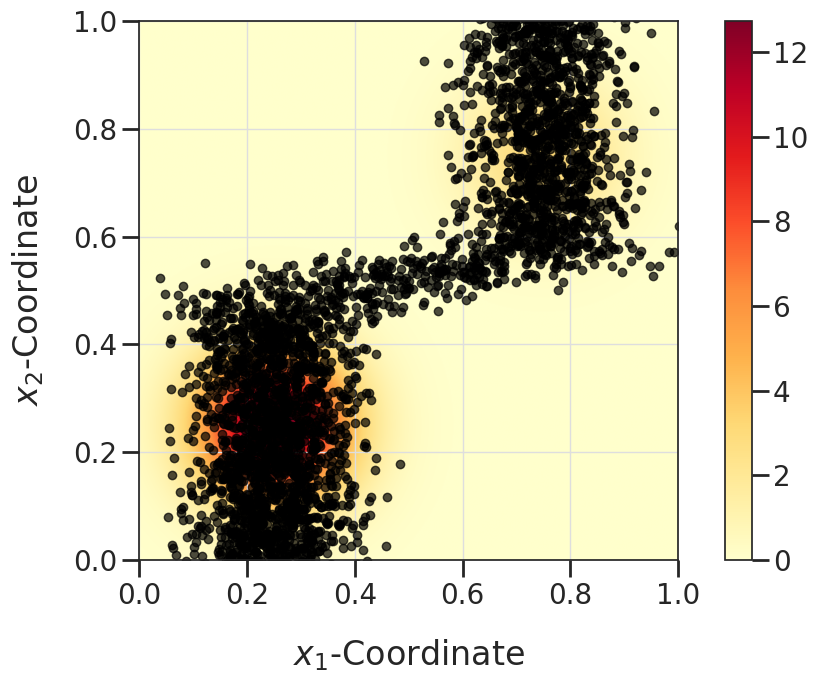

In [16]:
coordinates = [[[x,y] for x in np.linspace(*toy.xlim, 1000)] for y in np.linspace(*toy.ylim, 1000)]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]], origin='lower', cmap='YlOrRd')

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

### 2.1.2 TarFlow on TwoGaussians

In [17]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
data_shape = tuple(range(len(next(iter(train_loader)).shape)))[1:]

K = 6
T = 6
in_channel_size = 1
hidden_channel_size = 24
head_channel_size = 8
expansion = 4
patch_size = 1

base_dist = GaussianBase((x_sample_size, 1))
perms = [
    PermutationIdentity(x_sample_size), PermutationFlip(x_sample_size)]
trafo_blocks = []
for t in range(T):
    attn_blocks = []
    for k in range(K):
        attn_blocks.append(ResidualAttentionBlock(
            hidden_channel_size, head_channel_size, expansion=expansion))
    trafo_blocks.append(TarFlowBlock(
        perms[t % 2], nn.ModuleList(attn_blocks), in_channel_size,
        hidden_channel_size, x_sample_size
    ))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [19]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
epochs = 3
scheduler = CosineLRSchedule(
    optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

for epoch in range(epochs):
    data_iter = iter(train_loader)
    for x in data_iter:
        optimizer.zero_grad()

        x = x.to(DEVICE).unsqueeze(-1)
        z, log_dets = model(x)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy1_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|██████████| 3000/3000 [04:18<00:00, 11.62it/s, epoch=3/3, loss=⠀     -1.1555]


In [25]:
progress_bar.reset()

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [20]:
epochs = 3
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy1_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.forward_flow((10000,), show_path=True).squeeze(-1)
    samples_all = samples_all.detach().cpu().numpy()

/home/alzub/tmp/ipykernel_1056943/2919033565.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


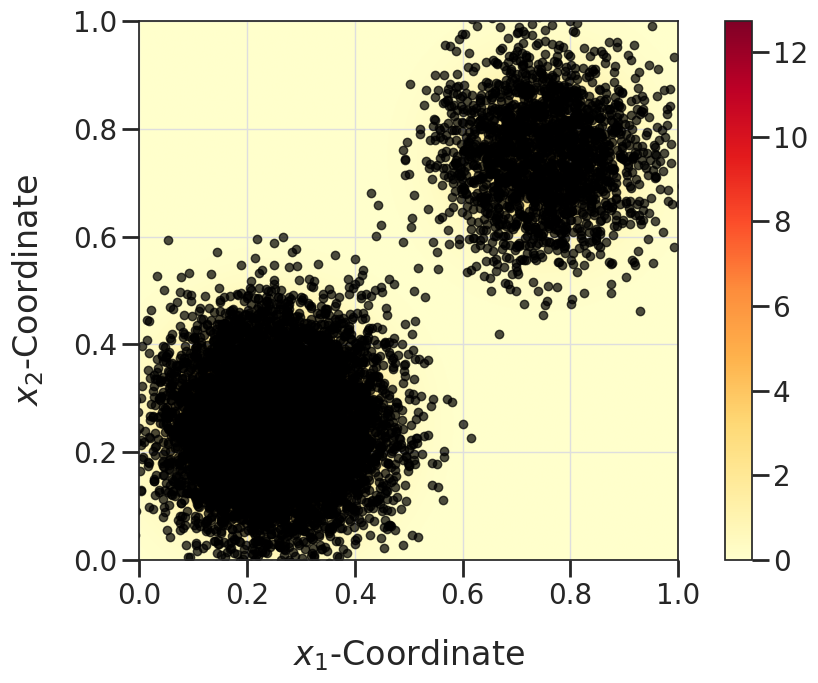

In [21]:
coordinates = [[[x,y] for x in np.linspace(*toy.xlim, 1000)] for y in np.linspace(*toy.ylim, 1000)]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]], origin='lower', cmap='YlOrRd')

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

## 2.2 Chequerboard

In [22]:
# Generate the data
n_data = 10000000
toy = Chequerboard(bounds=[-2, 2])
train_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    toy().sample((n_data,)), batch_size=10000, shuffle=True)

### 2.2.1 RealNVP on Chequerboard

In [ ]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
data_shape = tuple(range(len(next(iter(train_loader)).shape)))[1:]

K = 6
T = 6
hidden_size = 24

base_dist = GaussianBase((x_sample_size,))
trafo_blocks = []
for t in range(T):
    trafo_blocks.append(RealNVPBlock(
        PermutationFlip(x_sample_size),
        MLP(
            x_sample_size // 2, x_sample_size // 2,
            hidden_sizes=[hidden_size]*(K-1),
            act_funs=[nn.GELU]*(K-1) + [nn.Tanh]
        ),
        MLP(
            x_sample_size // 2, x_sample_size // 2,
            hidden_sizes=[hidden_size]*(K-1),
            act_funs=[nn.GELU]*(K-1) + [nn.Tanh]
        )
    ))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [ ]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
epochs = 3
scheduler = CosineLRSchedule(
    optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

for epoch in range(epochs):
    data_iter = iter(train_loader)
    for x in data_iter:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        z, log_dets = model(x)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy2_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|█████████▉| 2999/3000 [03:17<00:00, 19.13it/s, epoch=3/3, loss=⠀      1.5464]

Training: 100%|██████████| 3000/3000 [03:35<00:00, 19.13it/s, epoch=3/3, loss=⠀      1.5464]

In [29]:
progress_bar.reset()

In [33]:
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy2_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.forward_flow((10000,), show_path=True).squeeze(-1)
    samples_all = samples_all.detach().cpu().numpy()

/home/alzub/tmp/ipykernel_1056943/307483489.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


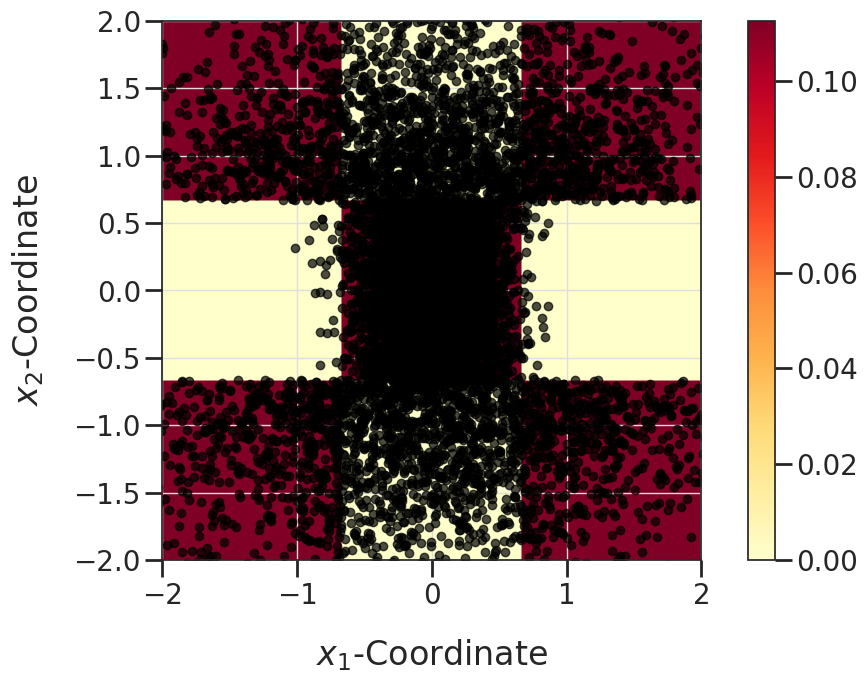

In [34]:
coordinates = [[[x,y] for x in np.linspace(*toy.xlim, 1000)] for y in np.linspace(*toy.ylim, 1000)]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]], origin='lower', cmap='YlOrRd')

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

### 2.2.2 TarFlow on Chequerboard

In [35]:
x_sample = next(iter(train_loader))[0]
x_sample_size = x_sample.size(-1)
data_shape = tuple(range(len(next(iter(train_loader)).shape)))[1:]

K = 6
T = 6
in_channel_size = 1
hidden_channel_size = 24
head_channel_size = 8
expansion = 4
patch_size = 1

base_dist = GaussianBase((x_sample_size, 1))
perms = [
    PermutationIdentity(x_sample_size), PermutationFlip(x_sample_size)]
trafo_blocks = []
for t in range(T):
    attn_blocks = []
    for k in range(K):
        attn_blocks.append(ResidualAttentionBlock(
            hidden_channel_size, head_channel_size, expansion=expansion))
    trafo_blocks.append(TarFlowBlock(
        perms[t % 2], nn.ModuleList(attn_blocks), in_channel_size,
        hidden_channel_size, x_sample_size
    ))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [36]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
epochs = 3
scheduler = CosineLRSchedule(
    optimizer, len(train_loader), epochs * len(train_loader), 1e-6, lr)

total_steps = len(train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

for epoch in range(epochs):
    data_iter = iter(train_loader)
    for x in data_iter:
        optimizer.zero_grad()

        x = x.to(DEVICE).unsqueeze(-1)
        z, log_dets = model(x)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"toy2_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|██████████| 3000/3000 [11:05<00:00,  4.51it/s, epoch=3/3, loss=⠀      1.5464]


In [ ]:
progress_bar.reset()

In [37]:
epochs = 3
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)
model.load_state_dict(torch.load(
    MODEL_DIR / f"toy2_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))
with torch.no_grad():
    model.eval()
    samples_all = model.forward_flow((10000,), show_path=True).squeeze(-1)
    samples_all = samples_all.detach().cpu().numpy()

/home/alzub/tmp/ipykernel_1056943/2961155904.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


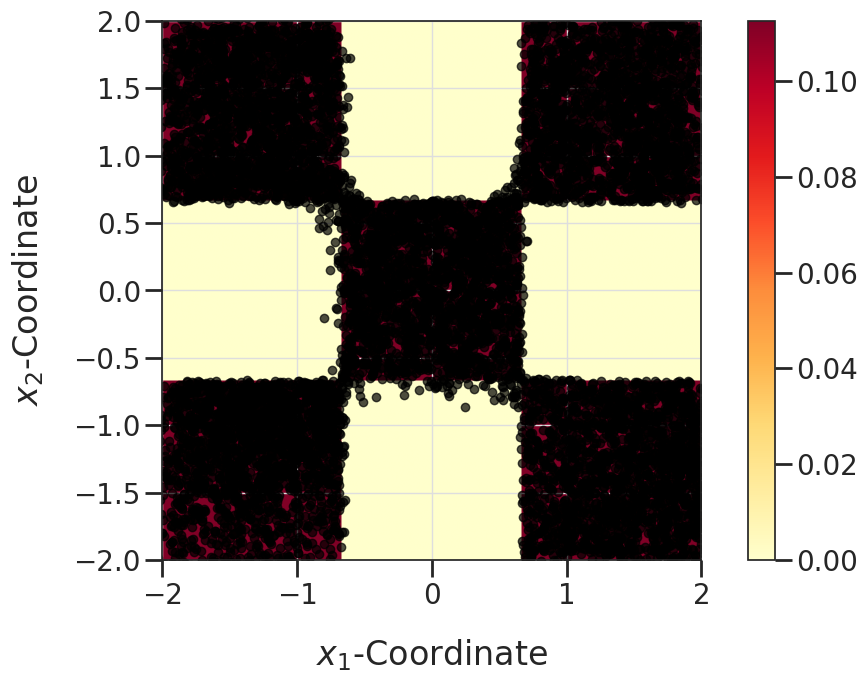

In [38]:
coordinates = [[[x,y] for x in np.linspace(*toy.xlim, 1000)] for y in np.linspace(*toy.ylim, 1000)]
prob = torch.exp(toy().log_prob(torch.tensor(coordinates)))

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

im = ax.imshow(
    prob, extent=[toy.xlim[0], toy.xlim[1], toy.ylim[0], toy.ylim[1]], origin='lower', cmap='YlOrRd')

ax.scatter(
    samples_all[-1, :, 0], samples_all[-1, :, 1], alpha=0.7, color="black")
ax.set_xlim(toy.xlim)
ax.set_ylim(toy.ylim)
ax.set_aspect('equal')
fig.colorbar(im)
ax.set_xlabel("$x_1$-Coordinate", labelpad=20)
ax.set_ylabel("$x_2$-Coordinate", labelpad=20)

plt.show()

# 3. NFs on Easy, Real Data

## 3.1 MNIST

### 3.1.1 RealNVP on MNIST

In [13]:
x_sample = next(iter(mnist_train_loader))[0][:1]
x_sample_size = x_sample.size()
data_size = x_sample_size[-1]

K = 4
T = 4
img_size = 28
in_channel_size = 1
hidden_channel_size = 128
cond_dim = 16
kernel_size = 3
padding = 1
n_classes = 10

trafo_blocks = []
new_hidden_size = in_channel_size
new_img_size = img_size
for t in range(T):
    masks = []
    coupling_blocks = []
    act_norms = []
    for k in range(K):
        invert_flag = (k % 2 == 1)
        if new_hidden_size == 1:
            masks.append(checkerboard_mask_2d(
                new_img_size, new_img_size, invert=invert_flag, device=DEVICE))
        else:
            masks.append(channel_mask(
                new_hidden_size, invert=invert_flag, device=DEVICE))
        
        coupling_blocks.append(FILMedCNN(
            Conv2DLayer(
                hidden_channel_size, hidden_channel_size, kernel_size, padding,
                pool=None, use_batchnorm=False, act_fun=None
            ), n_classes, cond_dim, new_hidden_size, hidden_channel_size,
            n_convs=4, act_fun=nn.GELU
        ))
        act_norms.append(ActNorm2d(new_hidden_size))
    
    if t % 2 == 0:
        new_hidden_size *= 4
        new_img_size //= 2
        squeeze = True
    else:
        squeeze = False
    trafo_blocks.append(RealNVPBlock(
        nn.ModuleList(coupling_blocks), nn.ModuleList(act_norms), masks,
        squeeze=squeeze
    ))

base_dist = GaussianBase((new_hidden_size, new_img_size, new_img_size))
model = NormalizingFlow(
    base_dist, nn.ModuleList(trafo_blocks), device=DEVICE).to(DEVICE)

In [ ]:
model.train()
lr = 5e-4
optimizer = torch.optim.AdamW(
    model.parameters(), betas=(0.9, 0.95), lr=lr, weight_decay=1e-4)
epochs = 10
scheduler = CosineLRSchedule(
    optimizer, len(mnist_train_loader), epochs * len(mnist_train_loader), 1e-6,
    lr
)

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

noise_std = 0.1

for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        x, log_det_prp = peprocess_realnvp(x)
        z, log_dets = model(x, y=y)
        loss = -((
            model.base().log_prob(z)
                + log_dets
                + log_det_prp
        ) / z[0].numel()).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_realnvp_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training: 100%|█████████▉| 2349/2350 [07:03<00:00,  5.58it/s, epoch=10/10, loss=⠀     -4.8124]

In [18]:
progress_bar.reset()

**Conditionally Trained Model**

In [30]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False).detach().cpu()
        all_samples.append(postprocess_realnvp(samples))
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/3962774388.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Conditionally Trained Model with Denoising**

In [24]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 1
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.05)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_realnvp_conditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=False, nrow=10
)

/home/alzub/tmp/ipykernel_2659529/2588349465.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance**

In [19]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, guidance=3.0).detach().cpu()
        all_samples.append(postprocess_realnvp(samples))
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=False, nrow=10
    )

/home/alzub/tmp/ipykernel_2659529/2419555124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance and Denoising**

In [23]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_realnvp_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 1
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, guidance=3.0).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.05)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_realnvp_unconditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=False, nrow=10
)

/home/alzub/tmp/ipykernel_2659529/1258741183.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


### 3.1.2 TarFlow on MNIST

In [20]:
x_sample = next(iter(mnist_train_loader))[0][:1]
x_sample_size = x_sample.size()
data_size = x_sample_size[-1]

K = 4
T = 4
in_channel_size = 1
hidden_channel_size = 128
head_channel_size = 64
expansion = 4
patch_size = 4
n_patches = (data_size // patch_size)**2

base_dist = GaussianBase((n_patches, in_channel_size * patch_size**2))
perms = [
    PermutationIdentity(n_patches), PermutationFlip(n_patches)]
trafo_blocks = []
for t in range(T):
    attn_blocks = []
    for k in range(K):
        attn_blocks.append(ResidualAttentionBlock(
            hidden_channel_size, head_channel_size, expansion=expansion))
    trafo_blocks.append(TarFlowBlock(
        perms[t % 2], nn.ModuleList(attn_blocks),
        in_channel_size * patch_size**2, hidden_channel_size, n_patches,
        n_classes=10
    ))
model = NFPatchified(
    base_dist, nn.ModuleList(trafo_blocks), patch_size, data_size, device=DEVICE
).to(DEVICE)

In [14]:
x_sample.min(), x_sample.max()

(tensor(-1.), tensor(1.))

In [ ]:
model.train()
lr = 2e-3
optimizer = torch.optim.AdamW(
    model.parameters(), betas=(0.9, 0.95), lr=lr, weight_decay=1e-4)
epochs = 10
scheduler = CosineLRSchedule(
    optimizer, len(mnist_train_loader), epochs * len(mnist_train_loader), 1e-6,
    lr
)

total_steps = len(mnist_train_loader)*epochs
progress_bar = tqdm(range(total_steps), desc="Training")

noise_std = 0.1

for epoch in range(epochs):
    for x, y in mnist_train_loader:
        optimizer.zero_grad()

        x = x.to(DEVICE)
        x = x + noise_std*torch.randn_like(x)
        z, log_dets = model(x, y=y)
        loss = -((model.base().log_prob(z) / z[0].numel()) + log_dets).mean()

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Update progress bar
        progress_bar.set_postfix(
            loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
        progress_bar.update()

torch.save(
    model.state_dict(),
    MODEL_DIR / f"mnist_tarflow_{epochs}_n_epochs_{K*T}_n_trafo.pt"
)

Training:  26%|██▌       | 6144/23500 [07:39<22:09, 13.05it/s, epoch=27/100, loss=⠀     -1.6020]

KeyboardInterrupt: 

In [101]:
progress_bar.reset()

**Conditionally Trained Model**

In [27]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=True, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/1419282849.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Conditionally Trained Model with Denoising**

In [24]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_conditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 3
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.1)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_tarflow_conditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=True, nrow=10
)

/home/alzub/tmp/ipykernel_2646961/962409240.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditionally Trained Model with Guidance**

In [22]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

# Generate samples
model.eval()
with torch.no_grad():
    all_samples = []
    for i in range(10):
        y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3
        ).detach().cpu()
        all_samples.append(samples)
    samples = torch.cat(all_samples)
    save_image(
        samples.view(100, 1, 28, 28),
        SAMPLE_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.png",
        normalize=True, nrow=10
    )

/home/alzub/tmp/ipykernel_2646961/3513593038.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


**Unconditional Model with Guidance and Denoising**

In [23]:
epochs = 100
model.load_state_dict(torch.load(
    MODEL_DIR / f"mnist_tarflow_unconditional_{epochs}_n_epochs_{K*T}_n_trafo.pt",
    map_location=torch.device(DEVICE)
))

n_denoising = 3
# Generate samples
model.eval()
all_samples = []
for i in range(10):
    y = torch.ones((10,), dtype=torch.long).to(DEVICE) * i
    with torch.no_grad():
        samples = model.forward_flow(
            (10,), y=y, show_path=False, caching=True, guidance=3).detach().cpu()
    for i in range(n_denoising):
        samples = tweedie_denoise(model, samples, y, 0.1)
    all_samples.append(samples)
samples = torch.cat(all_samples)
save_image(
    samples.view(100, 1, 28, 28),
    SAMPLE_DIR / f"mnist_tarflow_unconditional_denoised_{epochs}_n_epochs_{K*T}_n_trafo.png",
    normalize=True, nrow=10
)

/home/alzub/tmp/ipykernel_2646961/685461037.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
